In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os 
from sklearn.cluster import KMeans
os.chdir("/Users/AlanHDLR/Desktop")

# Carga de datos (Excel)
df_calendario = pd.read_excel('DIM_CALENDAR (2).xlsx')
df_segmento   = pd.read_excel('DIM_SEGMENT (1).xlsx')
df_producto   = pd.read_excel('DIM_PRODUCT (1).xlsx')

# Carga de datos (CSV)
df_categoria  = pd.read_csv('DIM_CATEGORY (2).csv')
df_ventas     = pd.read_csv('FACT_SALES (1).csv')

# Visualizamos las primeras 5 columnas de los datasets
print("DIM_CALENDAR")
print(df_calendario.head())
print("------------------------------------------------------------------------------")
print("DIM_SEGMENT")
print(df_segmento.head())
print("------------------------------------------------------------------------------")
print("DIM_PRODUCT")
print(df_producto.head())
print("------------------------------------------------------------------------------")
print("DIM_CATEGORY")
print(df_categoria.head())
print("------------------------------------------------------------------------------")
print("FACT_SALES")
print(df_ventas.head())

DIM_CALENDAR
    WEEK  YEAR  MONTH  WEEK_NUMBER       DATE
0  01-21  2021      1            1 2021-01-10
1  02-21  2021      1            2 2021-01-17
2  03-21  2021      1            3 2021-01-24
3  04-21  2021      1            4 2021-01-31
4  05-21  2021      2            5 2021-02-07
------------------------------------------------------------------------------
DIM_SEGMENT
   CATEGORY  ATTR1  ATTR2      ATTR3   FORMAT SEGMENT
0         1  CLORO  CLORO    BAMBINO  LIQUIDO  BLEACH
1         1  CLORO  CLORO  GERMICIDA  LIQUIDO  BLEACH
2         1  CLORO  CLORO   MASCOTAS  LIQUIDO  BLEACH
3         1  CLORO  CLORO  MULTIUSOS      GEL  BLEACH
4         1  CLORO  CLORO  MULTIUSOS  LIQUIDO  BLEACH
------------------------------------------------------------------------------
DIM_PRODUCT
  MANUFACTURER     BRAND           ITEM  \
0   INDS. ALEN  CLORALEX  0000075000592   
1   INDS. ALEN  CLORALEX  0000075000608   
2   INDS. ALEN  CLORALEX  0000075000615   
3   INDS. ALEN  CLORALEX  0000075

In [6]:
# Convertir fechas a objetos datetime reales
df_calendario['DATE'] = pd.to_datetime(df_calendario['DATE'])

# Limpieza de nombres en Categorías (quitando caracteres raros como \r\n)
df_categoria['CATEGORY'] = df_categoria['CATEGORY'].str.replace(r'[\r\n]+', '', regex=True).str.strip()

# Asegurar que los IDs de producto sean strings (a veces los códigos largos se cargan mal como números)
df_ventas['ITEM_CODE'] = df_ventas['ITEM_CODE'].astype(str)
df_producto['ITEM'] = df_producto['ITEM'].astype(str)

# Unir las tablas principales para el análisis
df_master = df_ventas.merge(df_producto, left_on='ITEM_CODE', right_on='ITEM', how='left')
df_master = df_master.merge(df_categoria, left_on='CATEGORY', right_on='ID_CATEGORY', how='left')
df_master = df_master.merge(df_calendario, on='WEEK', how='left')

df_master

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,...,FORMAT,ATTR1,ATTR2,ATTR3,ID_CATEGORY,CATEGORY_y,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058792808BP2,VANISHOXIACTIONROSADOYPACK120GR+MMCRYSTALWHITE...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2022,8,34,2022-08-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058792778BP1,VANISHOXIACTIONROSABOTE900GR+MMCRYSTALWHITEDOY...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,2023-07-03
121998,26-23,7501058757630,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058757630,VANISH PODER O2 PRE-LAVADOR BOT.ATOM. 650 ML N...,...,LIQUIDO,PRELAVADOR,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,2023-07-03
121999,26-23,7501058753441,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7501058753441,VANISH PODER O2 DOYPACK 120 GR 7501058753441,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,2023-07-03
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO,RECKITT,VANISH,7702626204208BP1,VANISH PODER 02 INTELIGENCE SIN CLORO SOBRE 30...,...,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,1,FABRIC TREATMENT and SANIT,2023,7,26,2023-07-03


### Primero, transformamos la tabla de ventas (que tiene muchas filas por producto) en una tabla de perfiles únicos por producto.

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Agrupar y reseteamos los indices
df_productos_perf = df_master.groupby('ITEM_CODE').agg({
    'TOTAL_VALUE_SALES': 'sum',
    'TOTAL_UNIT_SALES': 'sum'
}).reset_index() 

# Recalcular precio y limpiar 
df_productos_perf['AVG_PRICE'] = df_productos_perf['TOTAL_VALUE_SALES'] / df_productos_perf['TOTAL_UNIT_SALES'].replace(0, 1)

df_resultado = pd.merge(
    df_productos_perf, 
    df_producto[['ITEM', 'ITEM_DESCRIPTION', 'CATEGORY', 'BRAND']], 
    left_on='ITEM_CODE', 
    right_on='ITEM', 
    how='left'
)

### Estandarizar las características

In [12]:
X = df_resultado[['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'AVG_PRICE']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 


In [14]:
# Definimos el modelo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Entrenamos y asignamos el cluster a cada producto
df_productos_perf['CLUSTER'] = kmeans.fit_predict(X_scaled)

print(df_productos_perf.head())

       ITEM_CODE  TOTAL_VALUE_SALES  TOTAL_UNIT_SALES  AVG_PRICE  CLUSTER
0  0000075000592             24.663             6.042   4.081927        0
1  0000075000608          12423.156          1423.786   8.725438        0
2  0000075000615         658584.568         46461.839  14.174742        2
3  0000075000622        1139233.787         48445.151  23.515951        2
4  0000075000639        1146849.632         28334.417  40.475498        2


In [15]:
# Agregamos 'numeric_only=True' para ignorar ITEM_CODE y otros textos
resumen_clusters = df_productos_perf.groupby('CLUSTER').mean(numeric_only=True)
print(resumen_clusters)

         TOTAL_VALUE_SALES  TOTAL_UNIT_SALES   AVG_PRICE
CLUSTER                                                 
0             22940.550818        899.226965   30.703011
1             25199.907738        185.900148  131.254125
2            981555.995667      41080.469000   26.055397


In [16]:
# Calculamos estadísticas descriptivas solo de las métricas
perfil = df_productos_perf.groupby('CLUSTER').agg({
    'TOTAL_VALUE_SALES': ['mean', 'sum'],
    'TOTAL_UNIT_SALES': ['mean', 'count'],
    'AVG_PRICE': 'mean'
})

# Renombramos para que sea fácil de leer
perfil.columns = ['Venta_Promedio', 'Venta_Total', 'Unidades_Promedio', 'Cant_Productos', 'Precio_Promedio']
print(perfil)

         Venta_Promedio  Venta_Total  Unidades_Promedio  Cant_Productos  \
CLUSTER                                                                   
0          22940.550818  6560997.534         899.226965             286   
1          25199.907738  1537194.372         185.900148              61   
2         981555.995667  2944667.987       41080.469000               3   

         Precio_Promedio  
CLUSTER                   
0              30.703011  
1             131.254125  
2              26.055397  


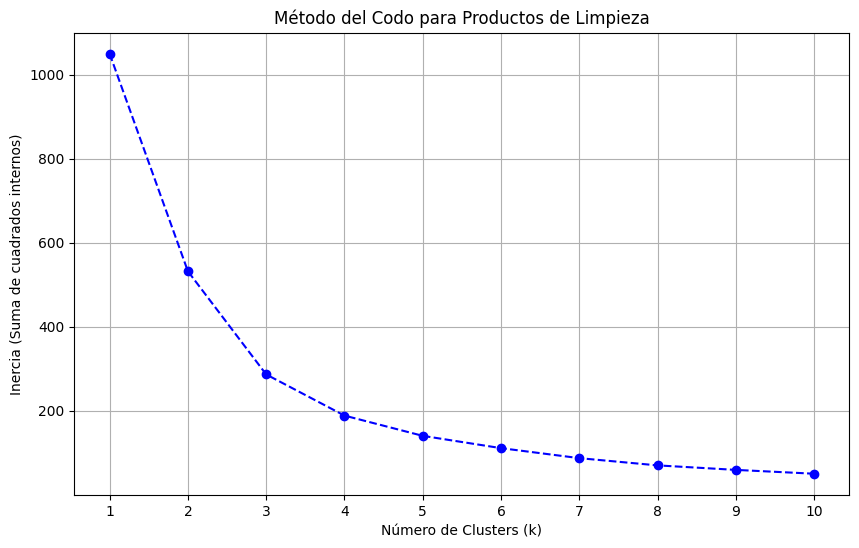

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Carga de datos
df_ventas = pd.read_csv('FACT_SALES (1).csv')
df_productos = pd.read_excel('DIM_PRODUCT (1).xlsx')

# Agrupamos por producto para obtener métricas clave
df_cluster = df_ventas.groupby('ITEM_CODE').agg({
    'TOTAL_VALUE_SALES': 'sum',
    'TOTAL_UNIT_SALES': 'sum'
}).reset_index()

# Calcular Precio Promedio para diferenciar segmentos Premium/Económicos
df_cluster['AVG_PRICE'] = df_cluster['TOTAL_VALUE_SALES'] / df_cluster['TOTAL_UNIT_SALES'].replace(0, 1)

# Manejamos nulos o infinitos
df_cluster = df_cluster.fillna(0).replace([np.inf, -np.inf], 0)

# Normalización
X = df_cluster[['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'AVG_PRICE']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ejecución del Método del Codo
wcss = []
k_rango = range(1, 11)

for i in k_rango:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(k_rango, wcss, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para Productos de Limpieza')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de cuadrados internos)')
plt.xticks(k_rango)
plt.grid(True)
plt.show()

In [22]:
df_cluster = df_ventas.groupby('ITEM_CODE').sum().reset_index()

In [24]:
# Agrupamos para que ITEM_CODE siga siendo una columna
df_productos_perf = df_master.groupby('ITEM_CODE', as_index=False).agg({
    'TOTAL_VALUE_SALES': 'sum',
    'TOTAL_UNIT_SALES': 'sum'
})

# Observamos las columnas existentes para trabajar con ellas
print("Columnas actuales:", df_productos_perf.columns.tolist())

df_productos_perf['CLUSTER'] = kmeans.labels_

# Creamos un merge para nombres, marcas y categorías
df_resultado = pd.merge(df_productos_perf, df_producto, left_on='ITEM_CODE', 
                        right_on='ITEM', how='left')

print(df_resultado[['ITEM_CODE', 'BRAND', 'TOTAL_VALUE_SALES', 'CLUSTER']].head())
df_resultado.head()

Columnas actuales: ['ITEM_CODE', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES']
       ITEM_CODE     BRAND  TOTAL_VALUE_SALES  CLUSTER
0  0000075000592  CLORALEX             24.663        8
1  0000075000608  CLORALEX          12423.156        8
2  0000075000615  CLORALEX         658584.568        6
3  0000075000622  CLORALEX        1139233.787        2
4  0000075000639  CLORALEX        1146849.632        9


,ITEM_CODE,TOTAL_VALUE_SALES,TOTAL_UNIT_SALES,CLUSTER,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3
0,0000075000592,24.663,6.042,8,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,0000075000608,12423.156,1423.786,8,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,0000075000615,658584.568,46461.839,6,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,0000075000622,1139233.787,48445.151,2,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,0000075000639,1146849.632,28334.417,9,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [26]:
df_resultado['AVG_PRICE'] = df_resultado['TOTAL_VALUE_SALES'] / df_resultado['TOTAL_UNIT_SALES'].replace(0, 1)

# Creamos un resumen por cluster
analisis_metrizado = df_resultado.groupby('CLUSTER').agg({
    'TOTAL_VALUE_SALES': 'mean',
    'TOTAL_UNIT_SALES': 'mean',
    'AVG_PRICE': 'mean',
    'ITEM_CODE': 'count'
}).rename(columns={'ITEM_CODE': 'CANTIDAD_PRODUCTOS'})

print(analisis_metrizado)

         TOTAL_VALUE_SALES  TOTAL_UNIT_SALES   AVG_PRICE  CANTIDAD_PRODUCTOS
CLUSTER                                                                     
0             1.497198e+04        379.300160   42.880582                  81
1             5.433584e+04        275.704273  208.027380                  11
2             1.139234e+06      48445.151000   23.515951                   1
3             3.017243e+05      11914.886500   25.237521                   6
4             1.723306e+04        134.286206  125.092355                  34
5             1.004089e+05       4687.529591   24.105327                  22
6             6.585846e+05      46461.839000   14.174742                   1
7             1.918029e+04        246.480694   76.375008                  49
8             5.157409e+03        302.114625   16.310255                 144
9             1.146850e+06      28334.417000   40.475498                   1


C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_20788\2200227604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analisis_metrizado.index, y='AVG_PRICE', data=analisis_metrizado, palette='magma')


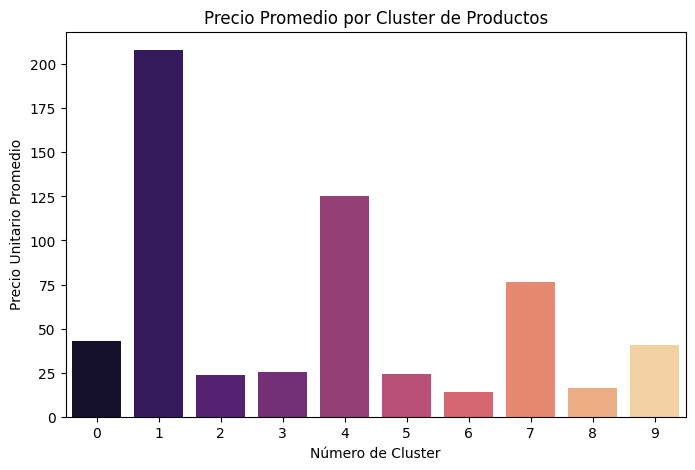

In [28]:
# Obtenemos el valor de los productos por cluster
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=analisis_metrizado.index, y='AVG_PRICE', data=analisis_metrizado, palette='magma')
plt.title('Precio Promedio por Cluster de Productos')
plt.xlabel('Número de Cluster')
plt.ylabel('Precio Unitario Promedio')
plt.show()

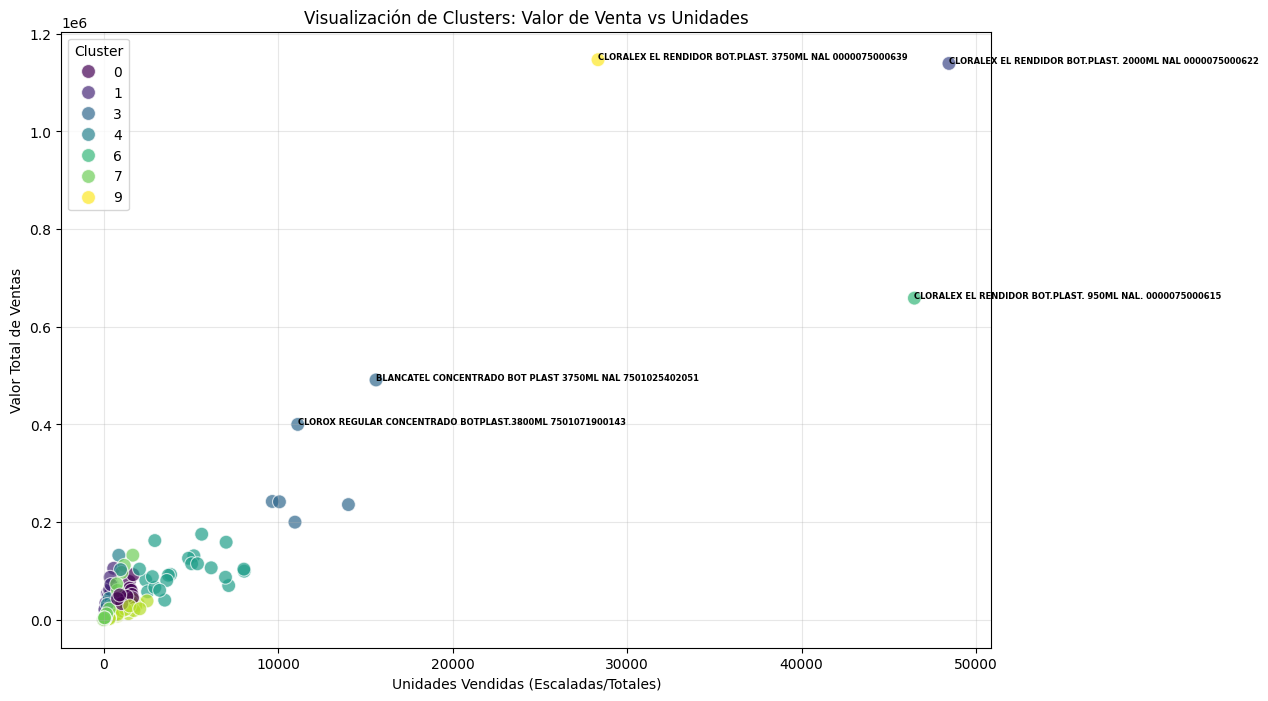

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
# Graficamos Unidades vs Valor de Venta
scatter = sns.scatterplot(data=df_resultado, x='TOTAL_UNIT_SALES', y='TOTAL_VALUE_SALES', 
                          hue='CLUSTER', palette='viridis', s=100, alpha=0.7)

# Añadimos etiquetas a los productos estrella
top_items = df_resultado.sort_values('TOTAL_VALUE_SALES', ascending=False).head(5)
for i in range(len(top_items)):
    plt.text(top_items.TOTAL_UNIT_SALES.iloc[i]+0.1, top_items.TOTAL_VALUE_SALES.iloc[i], 
             top_items.ITEM_DESCRIPTION.iloc[i], fontsize=6, weight='bold')

plt.title('Visualización de Clusters: Valor de Venta vs Unidades')
plt.xlabel('Unidades Vendidas (Escaladas/Totales)')
plt.ylabel('Valor Total de Ventas')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\AlanHDLR\AppData\Local\Temp\ipykernel_20788\1508011787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='CLUSTER', y='AVG_PRICE', data=df_resultado, palette='Set2')


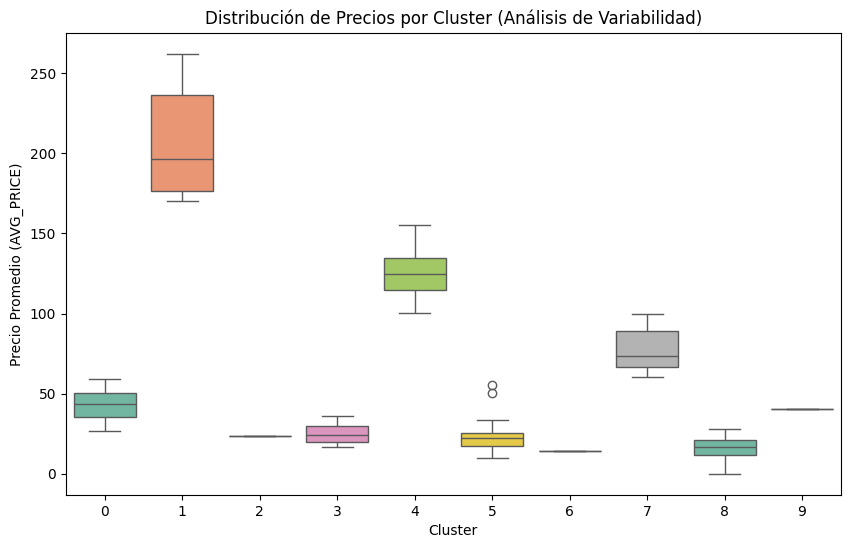

In [32]:
plt.figure(figsize=(10, 6))
# Comparamos cómo varía el precio promedio en cada cluster
sns.boxplot(x='CLUSTER', y='AVG_PRICE', data=df_resultado, palette='Set2')
plt.title('Distribución de Precios por Cluster (Análisis de Variabilidad)')
plt.xlabel('Cluster')
plt.ylabel('Precio Promedio (AVG_PRICE)')
plt.show()

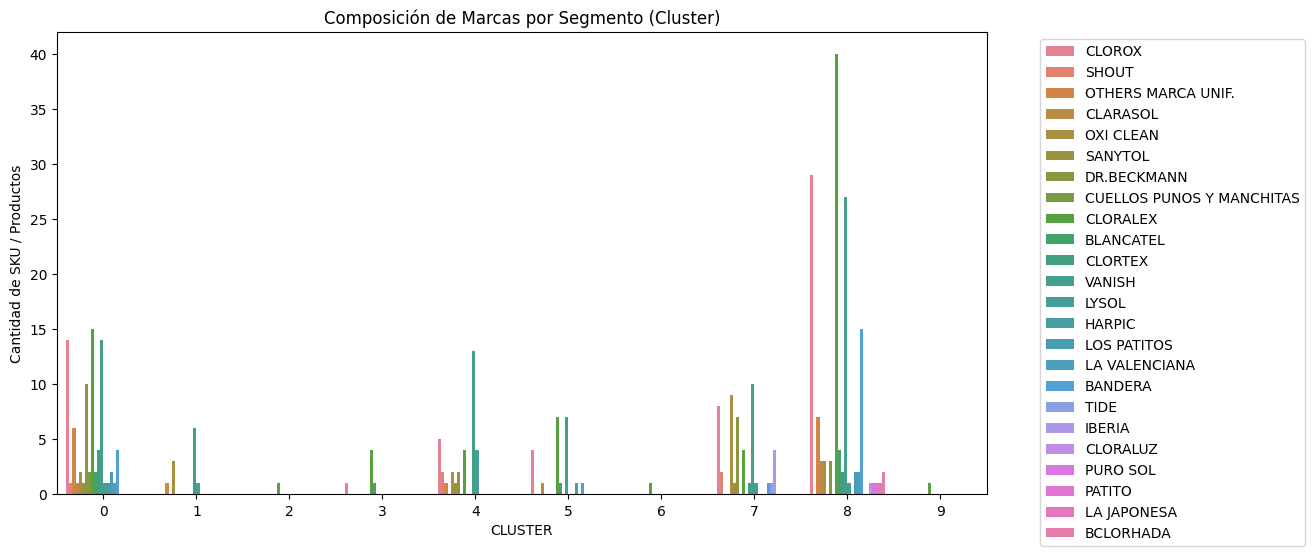

In [34]:
# Contamos cuántos productos de cada marca hay en cada cluster
plt.figure(figsize=(12, 6))
sns.countplot(data=df_resultado, x='CLUSTER', hue='BRAND') 
plt.title('Composición de Marcas por Segmento (Cluster)')
plt.ylabel('Cantidad de SKU / Productos')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [42]:
# Ver en qué clusters están los productos Vanish y sus ventas
analisis_vanish = df_resultado[df_resultado['BRAND'].str.contains('VANISH', case=False, na=False)]
print(analisis_vanish.groupby('CLUSTER').agg({'TOTAL_VALUE_SALES': ['sum', 'mean'], 'ITEM_CODE': 'count'}))

        TOTAL_VALUE_SALES                ITEM_CODE
                      sum           mean     count
CLUSTER                                           
0              293148.766   20939.197571        14
1              383026.378   63837.729667         6
4              305203.472   23477.190154        13
5              745199.527  106457.075286         7
7              358830.260   35883.026000        10
8               82881.122    3069.671185        27


In [46]:
# Seleccionamos las columnas más importantes para el reporte final
columnas_finales = [
    'ITEM_CODE', 'ITEM_DESCRIPTION', 'BRAND', 'CATEGORY', 
    'TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'AVG_PRICE', 'CLUSTER']

# Creamos el DataFrame final 
df_final_export = df_resultado[columnas_finales]

# Guardar en formato CSV 
df_final_export.to_csv('Fact_sales_final.csv', index=False)

print("¡Archivo 'segmentacion_productos_limpieza.csv' guardado con éxito!")

¡Archivo 'segmentacion_productos_limpieza.csv' guardado con éxito!
